# 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load Forecast Data

In [ ]:
df = pd.read_csv("/content/ganga_do_forecast_2016 .csv")

df.head()

,station_id,location,year,predicted_do,status
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,Safe
1,1,GANGA AT DAKSHINESHWAR,2016,7.379063,Safe
2,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,Safe
3,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,Safe
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,Safe


In [ ]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (9, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   station_id    9 non-null      int64  
 1   location      9 non-null      object 
 2   year          9 non-null      int64  
 3   predicted_do  9 non-null      float64
 4   status        9 non-null      object 
dtypes: float64(1), int64(2), object(2)
memory usage: 492.0+ bytes


# 3. Load Latest Water Quality Data

In [ ]:
water_quality = pd.read_csv(
    "/content/ganga_water_quality_features .csv")

water_quality.head()

,location,year,do,bod,fecal_coliform,do_good,bod_good,fecal_good,water_quality_score,year_index,station_id,do_lag1,bod_lag1,fecal_coliform_lag1,do_change,bod_change,fecal_coliform_change
0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2012,7.1,5.1,3450.0,1,0,0,1,1,0,7.2,4.0,3408.0,-0.1,1.1,42.0
1,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2013,8.2,3.6,6475.0,1,0,0,1,2,0,7.1,5.1,3450.0,1.1,-1.5,3025.0
2,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2014,8.6,3.8,26000.0,1,0,0,1,3,0,8.2,3.6,6475.0,0.4,0.2,19525.0
3,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2015,7.9,4.1,21300.0,1,0,0,1,4,0,8.6,3.8,26000.0,-0.7,0.3,-4700.0
4,GANGA AT DAKSHINESHWAR,2012,6.1,4.1,493750.0,1,0,0,1,1,1,7.8,4.0,270333.0,-1.7,0.1,223417.0


In [ ]:
latest_data = water_quality[
    water_quality["year"] == 2015
].copy()

latest_quality = latest_data[
    [
        "station_id",
        "location",
        "bod",
        "fecal_coliform"
    ]
].copy()

# 4. Select Required Columns

In [ ]:
latest_quality = latest_data[
    [
        "station_id",
        "location",
        "bod",
        "fecal_coliform"
    ]
].copy()

latest_quality.head()

,station_id,location,bod,fecal_coliform
3,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",4.1,21300.0
7,1,GANGA AT DAKSHINESHWAR,4.8,182500.0
11,2,GANGA AT GARHMUKTESHWAR,3.0,733.0
15,4,"GANGA AT KANNAUJ D/S, U.P",3.7,2930.0
19,5,GANGA AT KANNAUJ U/S (RAJGHAT),3.5,2270.0


# 5. Merge Forecast + Water Quality

In [ ]:
warning_df = df.merge(
    latest_quality,
    on=["station_id", "location"],
    how="left")

warning_df.head()

,station_id,location,year,predicted_do,status,bod,fecal_coliform
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,Safe,4.1,21300.0
1,1,GANGA AT DAKSHINESHWAR,2016,7.379063,Safe,4.8,182500.0
2,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,Safe,3.0,733.0
3,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,Safe,3.7,2930.0
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,Safe,3.5,2270.0


check:

In [ ]:
warning_df[[
        "station_id",
        "location",
        "predicted_do",
        "bod",
        "fecal_coliform"]]

,station_id,location,predicted_do,bod,fecal_coliform
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",7.747945,4.1,21300.0
1,1,GANGA AT DAKSHINESHWAR,7.379063,4.8,182500.0
2,2,GANGA AT GARHMUKTESHWAR,7.736700,3.0,733.0
3,4,"GANGA AT KANNAUJ D/S, U.P",7.764496,3.7,2930.0
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),7.776708,3.5,2270.0
5,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),7.759508,5.5,20889.0
6,7,GANGA AT KANPUR U/S (RANIGHAT),7.775426,2.9,3267.0
7,8,GANGA AT TRIGHAT (GHAZIPUR),7.783530,4.2,22000.0
8,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",7.753108,4.9,32500.0


# 6. Define Risk Conditions

 1. DO

DO > 5       → Good

DO 3–5       → Moderate

DO < 3       → Critical

2. BOD

DO > 5       → Good

DO 3–5       → Moderate

DO < 3       → Critical

3. Fecal Coliform

<= 500       → Good

> 500        → High

In [ ]:
warning_df["do_risk"] = np.where(
    warning_df["predicted_do"] < 3,
    2,
    np.where(
        warning_df["predicted_do"] <= 5,
        1,
        0
    )
)

warning_df["bod_risk"] = np.where(
    warning_df["bod"] > 3,
    1,
    0
)

warning_df["fecal_risk"] = np.where(
    warning_df["fecal_coliform"] > 500,
    1,
    0
)

# 7. Calculate Risk Score

In [ ]:
warning_df["risk_score"] = (
    warning_df["do_risk"]
    + warning_df["bod_risk"]
    + warning_df["fecal_risk"]
)

In [ ]:
warning_df["risk_level"] = np.select(
    [
        warning_df["risk_score"] >= 3,
        warning_df["risk_score"] >= 2,
        warning_df["risk_score"] >= 1
    ],
    [
        "High",
        "Medium",
        "Low"
    ],
    default="Safe"
)

check:

In [ ]:
early_warning = warning_df[
    [
        "station_id",
        "location",
        "year",
        "predicted_do",
        "bod",
        "fecal_coliform",
        "do_risk",
        "bod_risk",
        "fecal_risk",
        "risk_score",
        "risk_level"
    ]
].copy()

early_warning

,station_id,location,year,predicted_do,bod,fecal_coliform,do_risk,bod_risk,fecal_risk,risk_score,risk_level
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,4.1,21300.0,0,1,1,2,Medium
1,1,GANGA AT DAKSHINESHWAR,2016,7.379063,4.8,182500.0,0,1,1,2,Medium
2,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,3.0,733.0,0,0,1,1,Low
3,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,3.7,2930.0,0,1,1,2,Medium
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,3.5,2270.0,0,1,1,2,Medium
5,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2016,7.759508,5.5,20889.0,0,1,1,2,Medium
6,7,GANGA AT KANPUR U/S (RANIGHAT),2016,7.775426,2.9,3267.0,0,0,1,1,Low
7,8,GANGA AT TRIGHAT (GHAZIPUR),2016,7.783530,4.2,22000.0,0,1,1,2,Medium
8,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2016,7.753108,4.9,32500.0,0,1,1,2,Medium


In [ ]:
early_warning[
    [
        "station_id",
        "location",
        "predicted_do",
        "bod",
        "fecal_coliform",
        "do_risk",
        "bod_risk",
        "fecal_risk",
        "risk_score",
        "risk_level"
    ]
]

,station_id,location,predicted_do,bod,fecal_coliform,do_risk,bod_risk,fecal_risk,risk_score,risk_level
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",7.747945,4.1,21300.0,0,1,1,2,Medium
1,1,GANGA AT DAKSHINESHWAR,7.379063,4.8,182500.0,0,1,1,2,Medium
2,2,GANGA AT GARHMUKTESHWAR,7.736700,3.0,733.0,0,0,1,1,Low
3,4,"GANGA AT KANNAUJ D/S, U.P",7.764496,3.7,2930.0,0,1,1,2,Medium
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),7.776708,3.5,2270.0,0,1,1,2,Medium
5,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),7.759508,5.5,20889.0,0,1,1,2,Medium
6,7,GANGA AT KANPUR U/S (RANIGHAT),7.775426,2.9,3267.0,0,0,1,1,Low
7,8,GANGA AT TRIGHAT (GHAZIPUR),7.783530,4.2,22000.0,0,1,1,2,Medium
8,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",7.753108,4.9,32500.0,0,1,1,2,Medium


# 8. Generate Risk Level

In [ ]:
warning_df["risk_level"] = np.select(
    [
        warning_df["risk_score"] >= 3,
        warning_df["risk_score"] >= 2,
        warning_df["risk_score"] >= 1
    ],
    [
        "High",
        "Medium",
        "Low"
    ],
    default="Safe"
)

check:

In [ ]:
warning_df[
    [
        "station_id",
        "location",
        "predicted_do",
        "risk_score",
        "risk_level"
    ]
]

,station_id,location,predicted_do,risk_score,risk_level
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",7.747945,2,Medium
1,1,GANGA AT DAKSHINESHWAR,7.379063,2,Medium
2,2,GANGA AT GARHMUKTESHWAR,7.736700,1,Low
3,4,"GANGA AT KANNAUJ D/S, U.P",7.764496,2,Medium
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),7.776708,2,Medium
5,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),7.759508,2,Medium
6,7,GANGA AT KANPUR U/S (RANIGHAT),7.775426,1,Low
7,8,GANGA AT TRIGHAT (GHAZIPUR),7.783530,2,Medium
8,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",7.753108,2,Medium


# 9. Generate Warning Message

In [ ]:
warning_df["warning"] = np.select(
    [
        warning_df["risk_level"] == "High",
        warning_df["risk_level"] == "Medium",
        warning_df["risk_level"] == "Low"
    ],
    [
        "Immediate attention required",
        "Water quality requires monitoring",
        "Monitor water quality"
    ],
    default="No immediate warning"
)

# 10. Final Early Warning Table

In [ ]:
early_warning = warning_df[
    [
        "station_id",
        "location",
        "year",
        "predicted_do",
        "bod",
        "fecal_coliform",
        "risk_score",
        "risk_level",
        "warning"
    ]
].copy()

early_warning

,station_id,location,year,predicted_do,bod,fecal_coliform,risk_score,risk_level,warning
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,4.1,21300.0,2,Medium,Water quality requires monitoring
1,1,GANGA AT DAKSHINESHWAR,2016,7.379063,4.8,182500.0,2,Medium,Water quality requires monitoring
2,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,3.0,733.0,1,Low,Monitor water quality
3,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,3.7,2930.0,2,Medium,Water quality requires monitoring
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,3.5,2270.0,2,Medium,Water quality requires monitoring
5,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2016,7.759508,5.5,20889.0,2,Medium,Water quality requires monitoring
6,7,GANGA AT KANPUR U/S (RANIGHAT),2016,7.775426,2.9,3267.0,1,Low,Monitor water quality
7,8,GANGA AT TRIGHAT (GHAZIPUR),2016,7.783530,4.2,22000.0,2,Medium,Water quality requires monitoring
8,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2016,7.753108,4.9,32500.0,2,Medium,Water quality requires monitoring


# 11. Sort Stations by Risk

In [ ]:
early_warning = early_warning.sort_values(
    "risk_score",
    ascending=False
)

early_warning

,station_id,location,year,predicted_do,bod,fecal_coliform,risk_score,risk_level,warning
0,0,"GANGA AT ALLAHABAD D/S (SANGAM), U.P.",2016,7.747945,4.1,21300.0,2,Medium,Water quality requires monitoring
1,1,GANGA AT DAKSHINESHWAR,2016,7.379063,4.8,182500.0,2,Medium,Water quality requires monitoring
3,4,"GANGA AT KANNAUJ D/S, U.P",2016,7.764496,3.7,2930.0,2,Medium,Water quality requires monitoring
4,5,GANGA AT KANNAUJ U/S (RAJGHAT),2016,7.776708,3.5,2270.0,2,Medium,Water quality requires monitoring
5,6,GANGA AT KANPUR D/S (JAJMAU PUMPING STATION),2016,7.759508,5.5,20889.0,2,Medium,Water quality requires monitoring
8,9,"GANGA AT VARANASI D/S (MALVIYA BRIDGE), U.P",2016,7.753108,4.9,32500.0,2,Medium,Water quality requires monitoring
7,8,GANGA AT TRIGHAT (GHAZIPUR),2016,7.783530,4.2,22000.0,2,Medium,Water quality requires monitoring
2,2,GANGA AT GARHMUKTESHWAR,2016,7.736700,3.0,733.0,1,Low,Monitor water quality
6,7,GANGA AT KANPUR U/S (RANIGHAT),2016,7.775426,2.9,3267.0,1,Low,Monitor water quality


# 12. Risk Summary

In [ ]:
risk_summary = early_warning["risk_level"].value_counts()

risk_summary

,count
risk_level,
Medium,7
Low,2


Percentage:

In [ ]:
risk_percentage = (
    early_warning["risk_level"]
    .value_counts(normalize=True)
    * 100
)

risk_percentage

,proportion
risk_level,
Medium,77.777778
Low,22.222222


# 13. Risk Level Visualization

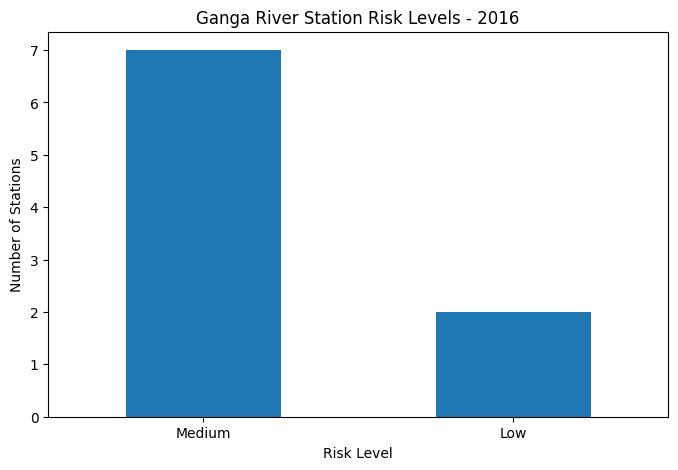

In [ ]:
plt.figure(figsize=(8, 5))

risk_summary.plot(
    kind="bar"
)

plt.title("Ganga River Station Risk Levels - 2016")
plt.xlabel("Risk Level")
plt.ylabel("Number of Stations")

plt.xticks(rotation=0)

plt.show()

# 14. Predicted DO + Risk

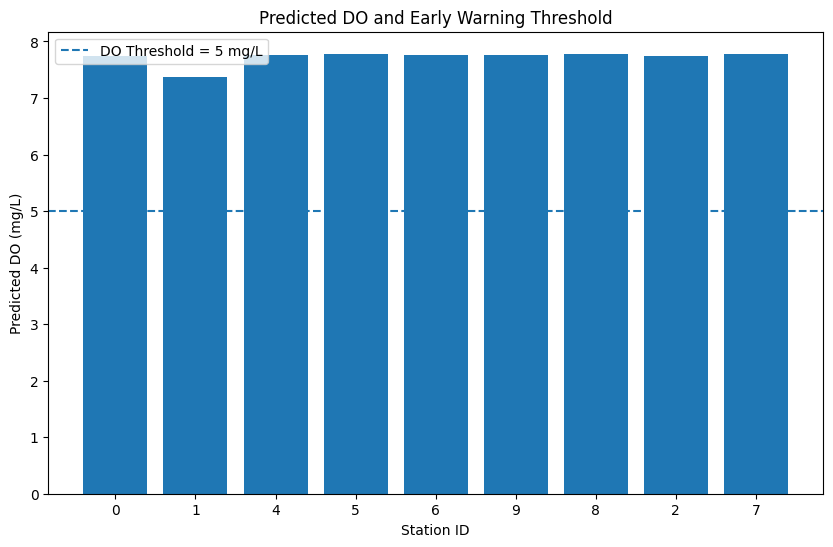

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    early_warning["station_id"].astype(str),
    early_warning["predicted_do"]
)

plt.axhline(
    y=5,
    linestyle="--",
    label="DO Threshold = 5 mg/L"
)

plt.title("Predicted DO and Early Warning Threshold")
plt.xlabel("Station ID")
plt.ylabel("Predicted DO (mg/L)")

plt.legend()

plt.show()

# 15. High-Risk Stations

In [ ]:
high_risk = early_warning[
    early_warning["risk_level"] == "High"
]

high_risk

,station_id,location,year,predicted_do,bod,fecal_coliform,risk_score,risk_level,warning


Number:

In [ ]:
print(
    "High-risk stations:",
    len(high_risk)
)

High-risk stations: 0


# 16. Save Early Warning Results

In [ ]:
early_warning.to_csv(
    "/content/ganga_early_warning_2016.csv",
    index=False
)

check:

In [ ]:
import os

print(
    os.path.exists(
        "/content/ganga_early_warning_2016.csv"
    )
)

True


# 17. Download CSV

In [ ]:
from google.colab import files

files.download(
    "/content/ganga_early_warning_2016.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 18. Final Findings

## Early Warning Findings

- An early-warning framework was developed for monitored Ganga River stations.
- Predicted Dissolved Oxygen (DO) was combined with recent BOD and Fecal Coliform measurements.
- A station-wise risk score was calculated using multiple water-quality indicators.
- Stations were classified into Safe, Low, Medium, and High risk levels.
- High-risk stations were flagged for immediate attention.
- The resulting early-warning dataset can be used by the Aquanga dashboard.
- The current warning system is a prototype and uses predefined threshold-based rules.
- Larger and more frequent water-quality observations would improve the reliability of the warning system.